# 🤖 Explainable Credit Risk Prediction

Compare classification models for hypothetical loan-default prediction.

In [2]:
# ============================================================
# CELL 1 — CREATE AND LOAD SYNTHETIC CREDIT DATA
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("EXPLAINABLE CREDIT RISK PREDICTION")
print("=" * 60)

# ------------------------------------------------------------
# 1. PROJECT LOCATION
# ------------------------------------------------------------

project_path = Path(
    r"C:\Masters\GitHub\Explainable-Credit-Risk-Prediction"
)

data_path = project_path / "data"

data_path.mkdir(
    parents=True,
    exist_ok=True
)

output_path = project_path / "outputs"

output_path.mkdir(
    parents=True,
    exist_ok=True
)

credit_file = (
    data_path /
    "sample_credit_data.csv"
)

print("\nProject folder:")
print(project_path)

print("\nDataset location:")
print(credit_file)

# ------------------------------------------------------------
# 2. GENERATE SYNTHETIC CREDIT DATA
# ------------------------------------------------------------

np.random.seed(42)

N = 10000

# ------------------------------------------------------------
# 3. CUSTOMER CHARACTERISTICS
# ------------------------------------------------------------

age = np.random.randint(
    21,
    70,
    N
)

income = np.random.lognormal(
    mean=10.5,
    sigma=0.5,
    size=N
)

income = np.round(
    np.clip(
        income,
        15000,
        250000
    ),
    2
)

employment_years = np.random.randint(
    0,
    35,
    N
)

# ------------------------------------------------------------
# 4. CREDIT CHARACTERISTICS
# ------------------------------------------------------------

credit_score = np.clip(
    np.random.normal(
        680,
        70,
        N
    ),
    300,
    850
).round().astype(int)

debt_to_income = np.clip(
    np.random.beta(
        2.2,
        5,
        N
    ),
    0.01,
    0.95
)

debt_to_income = np.round(
    debt_to_income,
    3
)

loan_amount = np.random.lognormal(
    mean=10.5,
    sigma=0.7,
    size=N
)

loan_amount = np.round(
    np.clip(
        loan_amount,
        1000,
        200000
    ),
    2
)

loan_term_months = np.random.choice(
    [12, 24, 36, 48, 60, 72, 84],
    size=N,
    p=[
        0.05,
        0.10,
        0.25,
        0.15,
        0.30,
        0.10,
        0.05
    ]
)

# ------------------------------------------------------------
# 5. CREDIT HISTORY
# ------------------------------------------------------------

existing_loans = np.random.poisson(
    1.5,
    N
)

existing_loans = np.clip(
    existing_loans,
    0,
    8
)

late_payments = np.random.poisson(
    1.2,
    N
)

late_payments = np.clip(
    late_payments,
    0,
    10
)

credit_history_years = np.clip(
    np.random.normal(
        8,
        5,
        N
    ),
    0.5,
    30
)

credit_history_years = np.round(
    credit_history_years,
    1
)

# ------------------------------------------------------------
# 6. HOME OWNERSHIP
# ------------------------------------------------------------

home_ownership = np.random.choice(
    [
        "Own",
        "Mortgage",
        "Rent"
    ],
    size=N,
    p=[
        0.25,
        0.40,
        0.35
    ]
)

# ------------------------------------------------------------
# 7. PURPOSE
# ------------------------------------------------------------

loan_purpose = np.random.choice(
    [
        "Debt Consolidation",
        "Home Improvement",
        "Education",
        "Medical",
        "Vehicle",
        "Other"
    ],
    size=N,
    p=[
        0.30,
        0.20,
        0.12,
        0.08,
        0.20,
        0.10
    ]
)

# ------------------------------------------------------------
# 8. SYNTHETIC DEFAULT PROBABILITY
# ------------------------------------------------------------

# The target is generated from a probabilistic relationship
# between credit-risk characteristics.

risk_score = (
    -2.0
    - 0.006 * (credit_score - 650)
    + 2.8 * debt_to_income
    + 0.11 * late_payments
    + 0.16 * existing_loans
    + 0.000004 * loan_amount
    - 0.000004 * income
    - 0.025 * employment_years
)

default_probability = (
    1 /
    (
        1 +
        np.exp(
            -risk_score
        )
    )
)

loan_default = (
    np.random.random(N)
    < default_probability
).astype(int)

# ------------------------------------------------------------
# 9. CREATE DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame({

    "customer_id": [
        f"CUST_{i:05d}"
        for i in range(1, N + 1)
    ],

    "age": age,

    "income": income,

    "employment_years": employment_years,

    "credit_score": credit_score,

    "debt_to_income": debt_to_income,

    "loan_amount": loan_amount,

    "loan_term_months": loan_term_months,

    "existing_loans": existing_loans,

    "late_payments": late_payments,

    "credit_history_years": credit_history_years,

    "home_ownership": home_ownership,

    "loan_purpose": loan_purpose,

    "loan_default": loan_default
})

# ------------------------------------------------------------
# 10. SAVE DATASET
# ------------------------------------------------------------

df.to_csv(
    credit_file,
    index=False
)

# ------------------------------------------------------------
# 11. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv(
    credit_file,
    low_memory=False
)

# ------------------------------------------------------------
# 12. DISPLAY DATASET
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET CREATED SUCCESSFULLY")
print("=" * 60)

print(
    f"\nRows       : {len(df):,}"
)

print(
    f"Columns    : {len(df.columns)}"
)

print(
    f"Default cases: "
    f"{df['loan_default'].sum():,}"
)

print(
    f"Default rate : "
    f"{df['loan_default'].mean() * 100:.2f}%"
)

print("\nSaved to:")
print(credit_file)

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nCELL 1 COMPLETED SUCCESSFULLY.")

EXPLAINABLE CREDIT RISK PREDICTION

Project folder:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction

Dataset location:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\data\sample_credit_data.csv

DATASET CREATED SUCCESSFULLY

Rows       : 10,000
Columns    : 14
Default cases: 2,297
Default rate : 22.97%

Saved to:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\data\sample_credit_data.csv

Dataset shape:
(10000, 14)

Columns:
['customer_id', 'age', 'income', 'employment_years', 'credit_score', 'debt_to_income', 'loan_amount', 'loan_term_months', 'existing_loans', 'late_payments', 'credit_history_years', 'home_ownership', 'loan_purpose', 'loan_default']

First 5 rows:


,customer_id,age,income,employment_years,credit_score,debt_to_income,loan_amount,loan_term_months,existing_loans,late_payments,credit_history_years,home_ownership,loan_purpose,loan_default
0,CUST_00001,59,21714.54,14,539,0.179,33004.47,60,1,1,5.3,Mortgage,Home Improvement,0
1,CUST_00002,49,23441.10,29,749,0.082,14837.64,24,0,3,15.6,Own,Vehicle,0
2,CUST_00003,35,49731.03,14,669,0.677,42052.05,36,1,0,3.3,Mortgage,Medical,0
3,CUST_00004,63,30373.16,22,603,0.552,41997.44,48,1,1,12.7,Own,Education,1
4,CUST_00005,28,84558.62,14,721,0.143,30543.53,60,1,1,10.9,Mortgage,Debt Consolidation,1



CELL 1 COMPLETED SUCCESSFULLY.


DATA QUALITY & EXPLORATORY DATA ANALYSIS

DATASET SHAPE
----------------------------------------
(10000, 14)

DATA TYPES
----------------------------------------


,Data Type
customer_id,object
age,int64
income,float64
employment_years,int64
credit_score,int64
debt_to_income,float64
loan_amount,float64
loan_term_months,int64
existing_loans,int64
late_payments,int64



MISSING VALUES
----------------------------------------


,Missing Values
customer_id,0
age,0
income,0
employment_years,0
credit_score,0
debt_to_income,0
loan_amount,0
loan_term_months,0
existing_loans,0
late_payments,0



DUPLICATE CUSTOMER IDs
----------------------------------------
Duplicate customer IDs: 0

DUPLICATE RECORDS
----------------------------------------
Duplicate rows: 0

NUMERICAL SUMMARY
----------------------------------------


...

loan_purpose
Debt Consolidation    3038
Home Improvement      1983
Vehicle               1967
Education             1215
Other                  977
Medical                820
Name: count, dtype: int64


DEFAULT RATE BY HOME OWNERSHIP
----------------------------------------


,transactions,defaults,default_rate
home_ownership,,,
Mortgage,3972,908,22.86
Own,2510,564,22.47
Rent,3518,825,23.45



DEFAULT RATE BY LOAN PURPOSE
----------------------------------------


,applications,defaults,default_rate
loan_purpose,,,
Debt Consolidation,3038,720,23.70
Education,1215,274,22.55
Home Improvement,1983,457,23.05
Medical,820,195,23.78
Other,977,219,22.42
Vehicle,1967,432,21.96


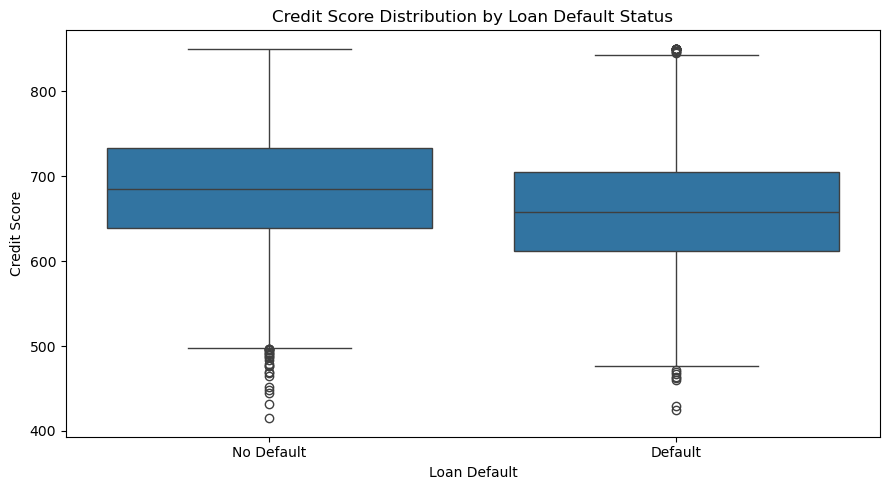

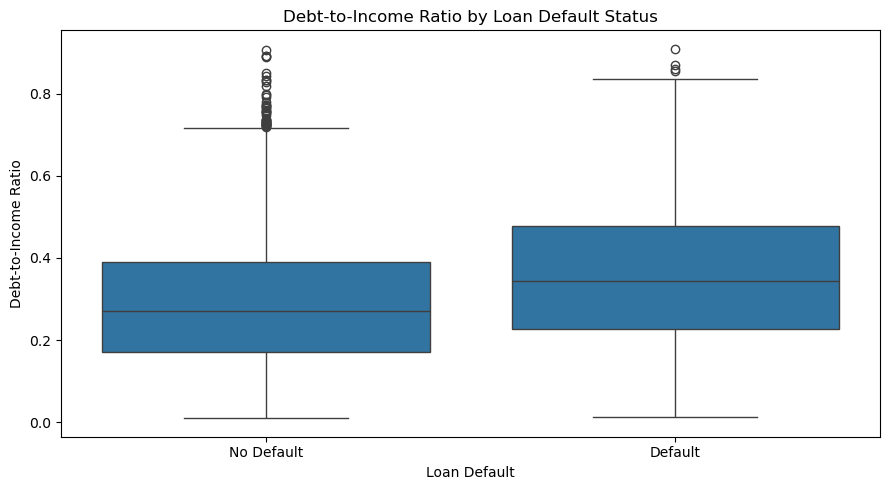

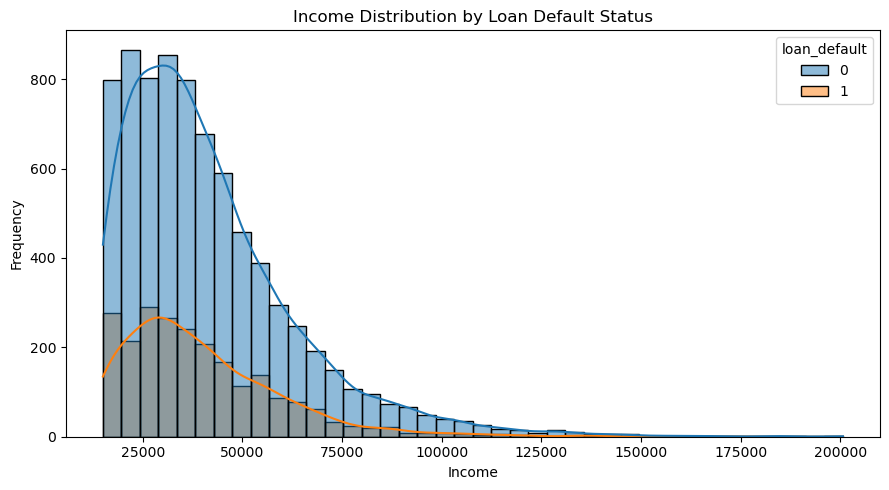

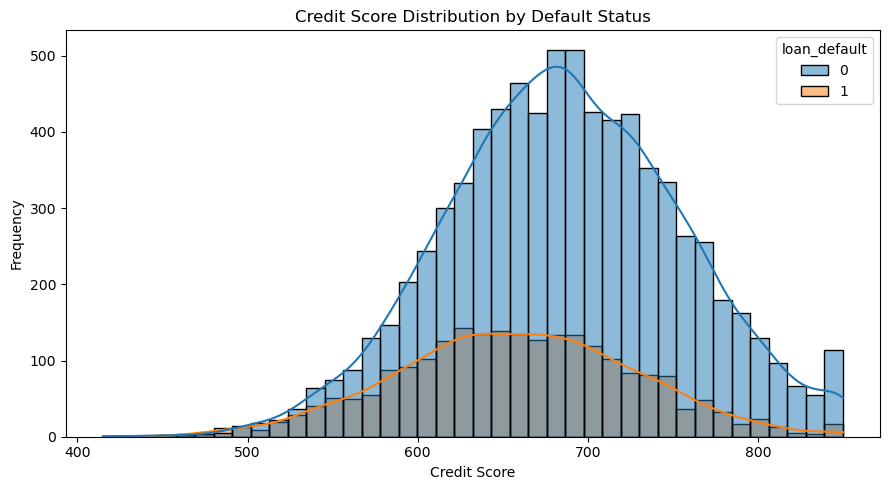


NUMERICAL CORRELATION WITH DEFAULT
----------------------------------------


loan_default            1.000
debt_to_income          0.180
existing_loans          0.075
late_payments           0.051
loan_amount             0.037
age                     0.016
credit_history_years    0.015
loan_term_months       -0.015
income                 -0.035
employment_years       -0.088
credit_score           -0.166
Name: loan_default, dtype: float64

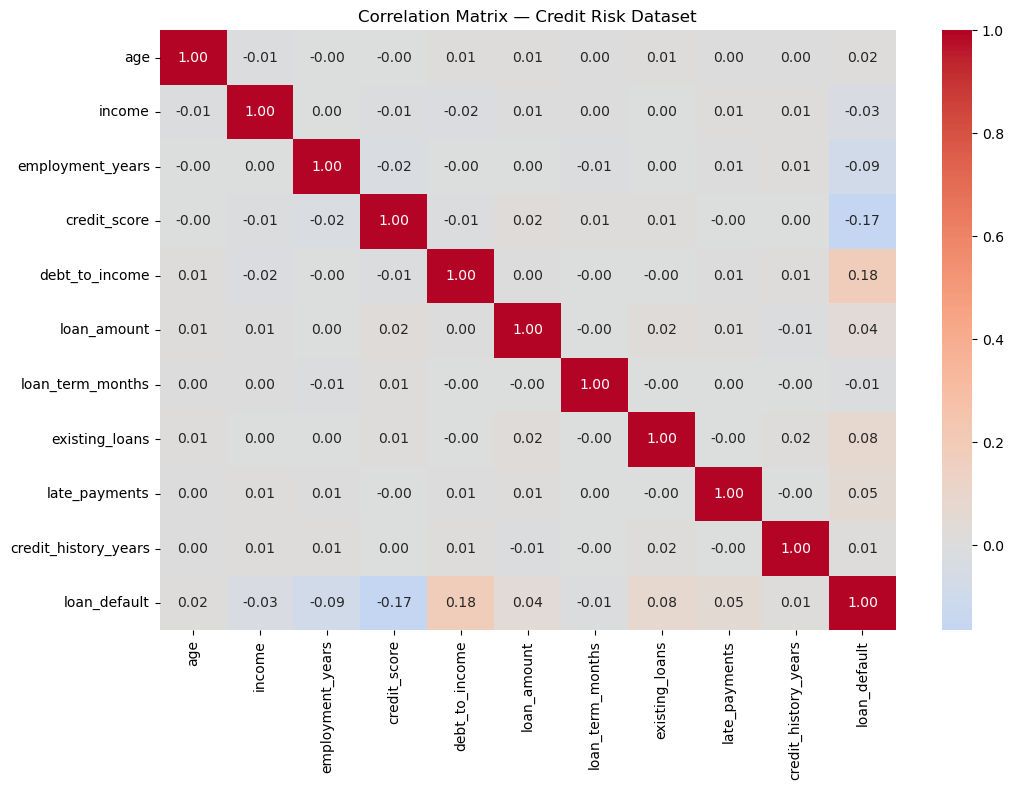


CELL 2 COMPLETED SUCCESSFULLY.


In [3]:
# ============================================================
# CELL 2 — DATA QUALITY & EXPLORATORY DATA ANALYSIS
# ============================================================

print("=" * 60)
print("DATA QUALITY & EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# DATASET SHAPE
# ------------------------------------------------------------

print("\nDATASET SHAPE")
print("-" * 40)

print(df.shape)

# ------------------------------------------------------------
# DATA TYPES
# ------------------------------------------------------------

print("\nDATA TYPES")
print("-" * 40)

display(
    pd.DataFrame({
        "Data Type": df.dtypes
    })
)

# ------------------------------------------------------------
# MISSING VALUES
# ------------------------------------------------------------

print("\nMISSING VALUES")
print("-" * 40)

missing_values = df.isnull().sum()

display(
    pd.DataFrame({
        "Missing Values": missing_values
    })
)

# ------------------------------------------------------------
# DUPLICATE CUSTOMERS
# ------------------------------------------------------------

print("\nDUPLICATE CUSTOMER IDs")
print("-" * 40)

duplicate_customers = df["customer_id"].duplicated().sum()

print(
    "Duplicate customer IDs:",
    duplicate_customers
)

# ------------------------------------------------------------
# DUPLICATE RECORDS
# ------------------------------------------------------------

print("\nDUPLICATE RECORDS")
print("-" * 40)

duplicate_rows = df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_rows
)

# ------------------------------------------------------------
# NUMERICAL SUMMARY
# ------------------------------------------------------------

print("\nNUMERICAL SUMMARY")
print("-" * 40)

display(
    df.describe().round(2)
)

# ------------------------------------------------------------
# DEFAULT DISTRIBUTION
# ------------------------------------------------------------

print("\nDEFAULT DISTRIBUTION")
print("-" * 40)

default_distribution = (
    df["loan_default"]
    .value_counts()
    .rename(index={
        0: "No Default",
        1: "Default"
    })
)

display(default_distribution)

# ------------------------------------------------------------
# DEFAULT PERCENTAGE
# ------------------------------------------------------------

print("\nDEFAULT PERCENTAGE")
print("-" * 40)

default_percentage = (
    df["loan_default"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={
        0: "No Default",
        1: "Default"
    })
    .round(2)
)

display(default_percentage)

# ------------------------------------------------------------
# HOME OWNERSHIP
# ------------------------------------------------------------

print("\nHOME OWNERSHIP DISTRIBUTION")
print("-" * 40)

display(
    df["home_ownership"]
    .value_counts()
)

# ------------------------------------------------------------
# LOAN PURPOSE
# ------------------------------------------------------------

print("\nLOAN PURPOSE DISTRIBUTION")
print("-" * 40)

display(
    df["loan_purpose"]
    .value_counts()
)

# ------------------------------------------------------------
# DEFAULT RATE BY HOME OWNERSHIP
# ------------------------------------------------------------

print("\nDEFAULT RATE BY HOME OWNERSHIP")
print("-" * 40)

home_default = (
    df.groupby("home_ownership")["loan_default"]
    .agg(
        transactions="count",
        defaults="sum",
        default_rate="mean"
    )
)

home_default["default_rate"] = (
    home_default["default_rate"] * 100
).round(2)

display(home_default)

# ------------------------------------------------------------
# DEFAULT RATE BY LOAN PURPOSE
# ------------------------------------------------------------

print("\nDEFAULT RATE BY LOAN PURPOSE")
print("-" * 40)

purpose_default = (
    df.groupby("loan_purpose")["loan_default"]
    .agg(
        applications="count",
        defaults="sum",
        default_rate="mean"
    )
)

purpose_default["default_rate"] = (
    purpose_default["default_rate"] * 100
).round(2)

display(purpose_default)

# ------------------------------------------------------------
# CREDIT SCORE VS DEFAULT
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="loan_default",
    y="credit_score"
)

plt.title(
    "Credit Score Distribution by Loan Default Status"
)

plt.xlabel(
    "Loan Default"
)

plt.ylabel(
    "Credit Score"
)

plt.xticks(
    [0, 1],
    ["No Default", "Default"]
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# DEBT-TO-INCOME VS DEFAULT
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="loan_default",
    y="debt_to_income"
)

plt.title(
    "Debt-to-Income Ratio by Loan Default Status"
)

plt.xlabel(
    "Loan Default"
)

plt.ylabel(
    "Debt-to-Income Ratio"
)

plt.xticks(
    [0, 1],
    ["No Default", "Default"]
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# INCOME DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="income",
    hue="loan_default",
    bins=40,
    kde=True
)

plt.title(
    "Income Distribution by Loan Default Status"
)

plt.xlabel(
    "Income"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# CREDIT SCORE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="credit_score",
    hue="loan_default",
    bins=40,
    kde=True
)

plt.title(
    "Credit Score Distribution by Default Status"
)

plt.xlabel(
    "Credit Score"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# CORRELATION ANALYSIS
# ------------------------------------------------------------

print("\nNUMERICAL CORRELATION WITH DEFAULT")
print("-" * 40)

numeric_columns = [
    "age",
    "income",
    "employment_years",
    "credit_score",
    "debt_to_income",
    "loan_amount",
    "loan_term_months",
    "existing_loans",
    "late_payments",
    "credit_history_years",
    "loan_default"
]

correlations = (
    df[numeric_columns]
    .corr()["loan_default"]
    .sort_values(ascending=False)
)

display(
    correlations.round(3)
)

# ------------------------------------------------------------
# CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix — Credit Risk Dataset"
)

plt.tight_layout()

plt.show()

print("\n" + "=" * 60)
print("CELL 2 COMPLETED SUCCESSFULLY.")
print("=" * 60)

In [4]:
# ============================================================
# CELL 3 — CREDIT RISK FEATURE ENGINEERING
# ============================================================

print("=" * 60)
print("CREDIT RISK FEATURE ENGINEERING")
print("=" * 60)

# Work on a copy
model_df = df.copy()

# ------------------------------------------------------------
# 1. LOG TRANSFORMATIONS
# ------------------------------------------------------------

# Reduce the effect of highly skewed financial variables

model_df["log_income"] = np.log1p(
    model_df["income"]
)

model_df["log_loan_amount"] = np.log1p(
    model_df["loan_amount"]
)

# ------------------------------------------------------------
# 2. LOAN-TO-INCOME RATIO
# ------------------------------------------------------------

model_df["loan_to_income_ratio"] = (
    model_df["loan_amount"] /
    model_df["income"]
)

# ------------------------------------------------------------
# 3. LOAN AMOUNT RELATIVE TO CREDIT SCORE
# ------------------------------------------------------------

model_df["loan_credit_score_ratio"] = (
    model_df["loan_amount"] /
    model_df["credit_score"]
)

# ------------------------------------------------------------
# 4. PAYMENT-BURDEN INDICATOR
# ------------------------------------------------------------

model_df["payment_burden_indicator"] = (
    model_df["loan_to_income_ratio"] *
    (model_df["loan_term_months"] / 12)
)

# ------------------------------------------------------------
# 5. CREDIT HISTORY / AGE RATIO
# ------------------------------------------------------------

model_df["credit_history_age_ratio"] = (
    model_df["credit_history_years"] /
    model_df["age"]
)

# ------------------------------------------------------------
# 6. LATE PAYMENT RATE
# ------------------------------------------------------------

model_df["late_payment_rate"] = (
    model_df["late_payments"] /
    (model_df["existing_loans"] + 1)
)

# ------------------------------------------------------------
# 7. LOAN BURDEN INDICATOR
# ------------------------------------------------------------

model_df["high_loan_burden"] = (
    (
        model_df["loan_to_income_ratio"] > 0.75
    )
    .astype(int)
)

# ------------------------------------------------------------
# 8. HIGH DTI INDICATOR
# ------------------------------------------------------------

model_df["high_dti"] = (
    (
        model_df["debt_to_income"] > 0.40
    )
    .astype(int)
)

# ------------------------------------------------------------
# 9. LOW CREDIT SCORE INDICATOR
# ------------------------------------------------------------

model_df["low_credit_score"] = (
    (
        model_df["credit_score"] < 600
    )
    .astype(int)
)

# ------------------------------------------------------------
# 10. LATE PAYMENT INDICATOR
# ------------------------------------------------------------

model_df["has_late_payments"] = (
    (
        model_df["late_payments"] > 0
    )
    .astype(int)
)

# ------------------------------------------------------------
# 11. MULTIPLE LOANS INDICATOR
# ------------------------------------------------------------

model_df["multiple_existing_loans"] = (
    (
        model_df["existing_loans"] >= 3
    )
    .astype(int)
)

# ------------------------------------------------------------
# 12. RISK INDICATOR COUNT
# ------------------------------------------------------------

model_df["risk_indicator_count"] = (
    model_df["high_loan_burden"]
    + model_df["high_dti"]
    + model_df["low_credit_score"]
    + model_df["has_late_payments"]
    + model_df["multiple_existing_loans"]
)

# ------------------------------------------------------------
# 13. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMissing values after feature engineering:")
display(
    model_df.isnull().sum()
)

# ------------------------------------------------------------
# 14. DISPLAY ENGINEERED FEATURES
# ------------------------------------------------------------

engineered_features = [
    "log_income",
    "log_loan_amount",
    "loan_to_income_ratio",
    "loan_credit_score_ratio",
    "payment_burden_indicator",
    "credit_history_age_ratio",
    "late_payment_rate",
    "high_loan_burden",
    "high_dti",
    "low_credit_score",
    "has_late_payments",
    "multiple_existing_loans",
    "risk_indicator_count"
]

print("\nEngineered features:")

display(
    model_df[
        engineered_features
    ].head()
)

# ------------------------------------------------------------
# 15. FEATURE SUMMARY
# ------------------------------------------------------------

print("\nFeature summary:")

display(
    model_df[
        engineered_features
    ].describe().round(3)
)

# ------------------------------------------------------------
# 16. RISK INDICATOR DISTRIBUTION
# ------------------------------------------------------------

print("\nRisk indicator count distribution:")

display(
    model_df[
        "risk_indicator_count"
    ]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 17. DEFAULT RATE BY RISK INDICATOR COUNT
# ------------------------------------------------------------

print("\nDefault rate by risk indicator count:")

risk_summary = (
    model_df
    .groupby("risk_indicator_count")["loan_default"]
    .agg(
        applications="count",
        defaults="sum",
        default_rate="mean"
    )
)

risk_summary["default_rate"] = (
    risk_summary["default_rate"] * 100
).round(2)

display(
    risk_summary
)

# ------------------------------------------------------------
# 18. SAVE FEATURE-ENGINEERED DATASET
# ------------------------------------------------------------

processed_path = (
    project_path /
    "data" /
    "credit_risk_model_data.csv"
)

model_df.to_csv(
    processed_path,
    index=False
)

print("\nFeature-engineered dataset saved to:")
print(processed_path)

print("\n" + "=" * 60)
print("CELL 3 COMPLETED SUCCESSFULLY.")
print("=" * 60)

CREDIT RISK FEATURE ENGINEERING

Missing values after feature engineering:


customer_id                 0
age                         0
income                      0
employment_years            0
credit_score                0
debt_to_income              0
loan_amount                 0
loan_term_months            0
existing_loans              0
late_payments               0
credit_history_years        0
home_ownership              0
loan_purpose                0
loan_default                0
log_income                  0
log_loan_amount             0
loan_to_income_ratio        0
loan_credit_score_ratio     0
payment_burden_indicator    0
credit_history_age_ratio    0
late_payment_rate           0
high_loan_burden            0
high_dti                    0
low_credit_score            0
has_late_payments           0
multiple_existing_loans     0
risk_indicator_count        0
dtype: int64


Engineered features:


,log_income,log_loan_amount,loan_to_income_ratio,loan_credit_score_ratio,payment_burden_indicator,credit_history_age_ratio,late_payment_rate,high_loan_burden,high_dti,low_credit_score,has_late_payments,multiple_existing_loans,risk_indicator_count
0,9.985783,10.404429,1.519925,61.232783,7.599624,0.089831,0.5,1,0,1,1,0,3
1,10.062289,9.604990,0.632975,19.809933,1.265951,0.318367,3.0,0,0,0,1,0,1
2,10.814404,10.646687,0.845590,62.858072,2.536769,0.094286,0.0,1,1,0,0,0,2
3,10.321348,10.645388,1.382716,69.647496,5.530862,0.201587,0.5,1,1,0,1,0,3
4,11.345212,10.326941,0.361211,42.362732,1.806057,0.389286,0.5,0,0,0,1,0,1



Feature summary:


...


Risk indicator count distribution:


risk_indicator_count
0     562
1    2774
2    4103
3    2123
4     414
5      24
Name: count, dtype: int64


Default rate by risk indicator count:


,applications,defaults,default_rate
risk_indicator_count,,,
0,562,60,10.68
1,2774,448,16.15
2,4103,920,22.42
3,2123,675,31.79
4,414,177,42.75
5,24,17,70.83



Feature-engineered dataset saved to:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\data\credit_risk_model_data.csv

CELL 3 COMPLETED SUCCESSFULLY.


In [5]:
# ============================================================
# CELL 4 — TRAIN / TEST SPLIT & PREPROCESSING
# ============================================================

print("=" * 60)
print("TRAIN / TEST SPLIT & MODEL PREPROCESSING")
print("=" * 60)

# ------------------------------------------------------------
# 1. DEFINE TARGET
# ------------------------------------------------------------

target = "loan_default"

# ------------------------------------------------------------
# 2. DEFINE FEATURES
# ------------------------------------------------------------

numeric_features = [
    "age",
    "income",
    "employment_years",
    "credit_score",
    "debt_to_income",
    "loan_amount",
    "loan_term_months",
    "existing_loans",
    "late_payments",
    "credit_history_years",
    "log_income",
    "log_loan_amount",
    "loan_to_income_ratio",
    "loan_credit_score_ratio",
    "payment_burden_indicator",
    "credit_history_age_ratio",
    "late_payment_rate",
    "high_loan_burden",
    "high_dti",
    "low_credit_score",
    "has_late_payments",
    "multiple_existing_loans",
    "risk_indicator_count"
]

categorical_features = [
    "home_ownership",
    "loan_purpose"
]

features = (
    numeric_features +
    categorical_features
)

# ------------------------------------------------------------
# 3. CREATE X AND y
# ------------------------------------------------------------

X = model_df[features].copy()

y = model_df[target].copy()

print("\nFeature matrix shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

# ------------------------------------------------------------
# 4. CHECK TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\nTarget distribution:")

display(
    y.value_counts()
    .rename(index={
        0: "No Default",
        1: "Default"
    })
)

print("\nTarget percentage:")

display(
    (
        y.value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename(index={
            0: "No Default",
            1: "Default"
        })
    )
)

# ------------------------------------------------------------
# 5. STRATIFIED TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTRAIN / TEST SPLIT")
print("-" * 40)

print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows :",
    len(X_test)
)

# ------------------------------------------------------------
# 6. CHECK CLASS BALANCE AFTER SPLIT
# ------------------------------------------------------------

print("\nTraining target distribution:")

display(
    y_train.value_counts()
    .rename(index={
        0: "No Default",
        1: "Default"
    })
)

print("\nTesting target distribution:")

display(
    y_test.value_counts()
    .rename(index={
        0: "No Default",
        1: "Default"
    })
)

# ------------------------------------------------------------
# 7. PREPROCESSING PIPELINE
# ------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ------------------------------------------------------------
# 8. TEST PREPROCESSING
# ------------------------------------------------------------

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("\nPREPROCESSING COMPLETED")
print("-" * 40)

print(
    "Original feature count:",
    X_train.shape[1]
)

print(
    "Processed feature count:",
    X_train_processed.shape[1]
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

# ------------------------------------------------------------
# 9. FEATURE NAMES AFTER ENCODING
# ------------------------------------------------------------

feature_names = (
    preprocessor
    .get_feature_names_out()
)

print("\nProcessed feature names:")

print(
    feature_names.tolist()
)

# ------------------------------------------------------------
# 10. SAVE PROCESSED FEATURE MATRIX
# ------------------------------------------------------------

processed_train = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

processed_train["loan_default"] = (
    y_train.values
)

processed_test = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

processed_test["loan_default"] = (
    y_test.values
)

train_output = (
    output_path /
    "processed_training_data.csv"
)

test_output = (
    output_path /
    "processed_testing_data.csv"
)

processed_train.to_csv(
    train_output,
    index=False
)

processed_test.to_csv(
    test_output,
    index=False
)

print("\nProcessed datasets saved:")

print(train_output)
print(test_output)

print("\n" + "=" * 60)
print("CELL 4 COMPLETED SUCCESSFULLY.")
print("=" * 60)

TRAIN / TEST SPLIT & MODEL PREPROCESSING

Feature matrix shape:
(10000, 25)

Target shape:
(10000,)

Target distribution:


loan_default
No Default    7703
Default       2297
Name: count, dtype: int64


Target percentage:


loan_default
No Default    77.03
Default       22.97
Name: proportion, dtype: float64


TRAIN / TEST SPLIT
----------------------------------------
Training rows: 8000
Testing rows : 2000

Training target distribution:


loan_default
No Default    6162
Default       1838
Name: count, dtype: int64


Testing target distribution:


loan_default
No Default    1541
Default        459
Name: count, dtype: int64


PREPROCESSING COMPLETED
----------------------------------------
Original feature count: 25
Processed feature count: 32
Processed training shape: (8000, 32)
Processed testing shape: (2000, 32)

Processed feature names:
['numerical__age', 'numerical__income', 'numerical__employment_years', 'numerical__credit_score', 'numerical__debt_to_income', 'numerical__loan_amount', 'numerical__loan_term_months', 'numerical__existing_loans', 'numerical__late_payments', 'numerical__credit_history_years', 'numerical__log_income', 'numerical__log_loan_amount', 'numerical__loan_to_income_ratio', 'numerical__loan_credit_score_ratio', 'numerical__payment_burden_indicator', 'numerical__credit_history_age_ratio', 'numerical__late_payment_rate', 'numerical__high_loan_burden', 'numerical__high_dti', 'numerical__low_credit_score', 'numerical__has_late_payments', 'numerical__multiple_existing_loans', 'numerical__risk_indicator_count', 'categorical__home_ownership_Mortgage', 'categorical__home_ownership_Own', '

LOGISTIC REGRESSION — CREDIT DEFAULT PREDICTION

Training Logistic Regression...
Training completed.

LOGISTIC REGRESSION RESULTS
Accuracy  : 0.781
Precision : 0.653
Recall    : 0.102
F1 Score  : 0.177
ROC-AUC   : 0.706

Detailed Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

  No Default       0.79      0.98      0.87      1541
     Default       0.65      0.10      0.18       459

    accuracy                           0.78      2000
   macro avg       0.72      0.54      0.53      2000
weighted avg       0.76      0.78      0.71      2000


Confusion Matrix
------------------------------------------------------------
[[1516   25]
 [ 412   47]]


<Figure size 700x500 with 0 Axes>

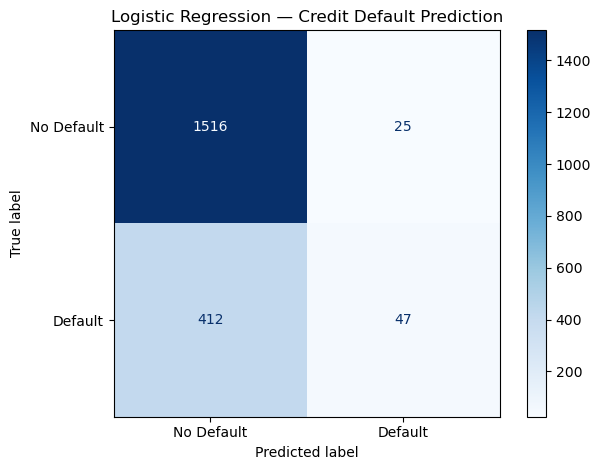


TOP 20 HIGHEST PREDICTED DEFAULT RISKS
------------------------------------------------------------


,age,income,credit_score,debt_to_income,loan_amount,late_payments,existing_loans,actual_default,predicted_default,default_probability
440,65,26139.68,654,0.626,154634.47,2,5,0,1,0.715
6147,37,15000.00,579,0.628,24325.77,2,3,1,1,0.691
6811,26,67146.93,548,0.726,69472.94,2,4,1,1,0.658
4848,23,17061.18,557,0.578,35142.17,3,4,0,1,0.658
3980,25,16943.46,581,0.661,36217.43,1,2,1,1,0.656
8786,49,48975.57,555,0.481,192872.93,1,2,1,1,0.644
5057,51,57677.81,619,0.733,12449.74,3,4,1,1,0.634
8102,62,26239.30,543,0.602,28536.92,1,3,1,1,0.627
6113,24,56066.69,547,0.689,36422.00,1,1,0,1,0.627
2047,54,44158.57,652,0.484,138131.69,2,5,0,1,0.624



Predictions saved to:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\outputs\logistic_regression_predictions.csv

CELL 5 COMPLETED SUCCESSFULLY.


In [6]:
# ============================================================
# CELL 5 — LOGISTIC REGRESSION CREDIT RISK MODEL
# ============================================================

print("=" * 60)
print("LOGISTIC REGRESSION — CREDIT DEFAULT PREDICTION")
print("=" * 60)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. CREATE LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# ------------------------------------------------------------
# 2. TRAIN MODEL
# ------------------------------------------------------------

print("\nTraining Logistic Regression...")

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# 3. GENERATE PREDICTIONS
# ------------------------------------------------------------

y_pred_logistic = logistic_model.predict(
    X_test_processed
)

y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

# ------------------------------------------------------------
# 4. CALCULATE METRICS
# ------------------------------------------------------------

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

# ------------------------------------------------------------
# 5. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(
    f"Accuracy  : {logistic_accuracy:.3f}"
)

print(
    f"Precision : {logistic_precision:.3f}"
)

print(
    f"Recall    : {logistic_recall:.3f}"
)

print(
    f"F1 Score  : {logistic_f1:.3f}"
)

print(
    f"ROC-AUC   : {logistic_roc_auc:.3f}"
)

# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nDetailed Classification Report")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "No Default",
            "Default"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 7. CONFUSION MATRIX
# ------------------------------------------------------------

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("\nConfusion Matrix")
print("-" * 60)

print(cm_logistic)

# ------------------------------------------------------------
# 8. VISUALISE CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=[
        "No Default",
        "Default"
    ]
).plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Logistic Regression — Credit Default Prediction"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 9. CREATE PREDICTION DATASET
# ------------------------------------------------------------

logistic_predictions = X_test.copy()

logistic_predictions["actual_default"] = (
    y_test.values
)

logistic_predictions["predicted_default"] = (
    y_pred_logistic
)

logistic_predictions["default_probability"] = (
    y_prob_logistic
)

# ------------------------------------------------------------
# 10. DISPLAY HIGHEST-RISK APPLICATIONS
# ------------------------------------------------------------

print("\nTOP 20 HIGHEST PREDICTED DEFAULT RISKS")
print("-" * 60)

display(
    logistic_predictions
    .sort_values(
        "default_probability",
        ascending=False
    )
    [
        [
            "age",
            "income",
            "credit_score",
            "debt_to_income",
            "loan_amount",
            "late_payments",
            "existing_loans",
            "actual_default",
            "predicted_default",
            "default_probability"
        ]
    ]
    .head(20)
    .round(3)
)

# ------------------------------------------------------------
# 11. SAVE PREDICTIONS
# ------------------------------------------------------------

logistic_output = (
    output_path /
    "logistic_regression_predictions.csv"
)

logistic_predictions.to_csv(
    logistic_output,
    index=False
)

print("\nPredictions saved to:")
print(logistic_output)

print("\n" + "=" * 60)
print("CELL 5 COMPLETED SUCCESSFULLY.")
print("=" * 60)

RANDOM FOREST — CREDIT DEFAULT PREDICTION

Training Random Forest...
Training completed.

RANDOM FOREST RESULTS
Accuracy  : 0.742
Precision : 0.426
Recall    : 0.366
F1 Score  : 0.394
ROC-AUC   : 0.691

Detailed Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

  No Default       0.82      0.85      0.84      1541
     Default       0.43      0.37      0.39       459

    accuracy                           0.74      2000
   macro avg       0.62      0.61      0.61      2000
weighted avg       0.73      0.74      0.73      2000


Confusion Matrix
------------------------------------------------------------
[[1315  226]
 [ 291  168]]


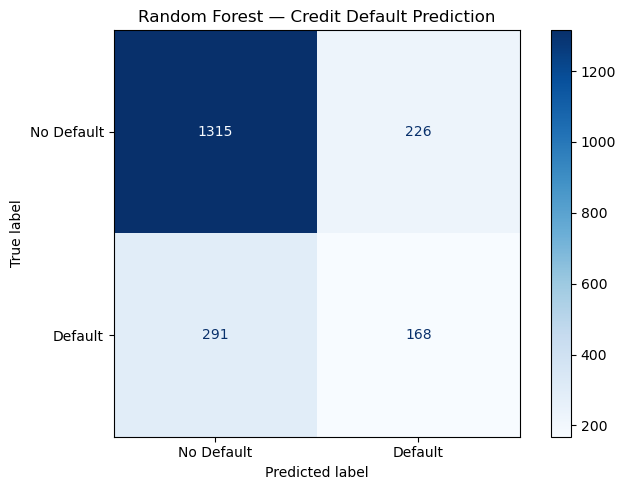


TOP 20 HIGHEST PREDICTED DEFAULT RISKS
------------------------------------------------------------


,age,income,credit_score,debt_to_income,loan_amount,late_payments,existing_loans,actual_default,predicted_default,default_probability
6811,26,67146.93,548,0.726,69472.94,2,4,1,1,0.774
3581,30,50112.55,534,0.442,46472.26,1,2,1,1,0.742
8147,60,40555.84,582,0.435,37492.84,1,1,1,1,0.724
2047,54,44158.57,652,0.484,138131.69,2,5,0,1,0.718
4359,49,27214.84,495,0.373,25485.65,1,0,1,1,0.710
8102,62,26239.30,543,0.602,28536.92,1,3,1,1,0.708
7684,28,38151.02,611,0.460,44163.80,1,1,0,1,0.707
2894,45,60406.83,493,0.200,23872.46,3,3,1,1,0.706
9107,51,39544.48,565,0.563,57303.34,1,0,1,1,0.705
858,26,35502.65,607,0.563,33848.77,1,3,0,1,0.702



Predictions saved to:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\outputs\random_forest_predictions.csv

CELL 6 COMPLETED SUCCESSFULLY.


In [7]:
# ============================================================
# CELL 6 — RANDOM FOREST CREDIT RISK MODEL
# ============================================================

print("=" * 60)
print("RANDOM FOREST — CREDIT DEFAULT PREDICTION")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. CREATE RANDOM FOREST MODEL
# ------------------------------------------------------------

rf_credit_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 2. TRAIN MODEL
# ------------------------------------------------------------

print("\nTraining Random Forest...")

rf_credit_model.fit(
    X_train_processed,
    y_train
)

print("Training completed.")

# ------------------------------------------------------------
# 3. GENERATE PREDICTIONS
# ------------------------------------------------------------

y_pred_rf = rf_credit_model.predict(
    X_test_processed
)

y_prob_rf = rf_credit_model.predict_proba(
    X_test_processed
)[:, 1]

# ------------------------------------------------------------
# 4. CALCULATE METRICS
# ------------------------------------------------------------

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# ------------------------------------------------------------
# 5. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(
    f"Accuracy  : {rf_accuracy:.3f}"
)

print(
    f"Precision : {rf_precision:.3f}"
)

print(
    f"Recall    : {rf_recall:.3f}"
)

print(
    f"F1 Score  : {rf_f1:.3f}"
)

print(
    f"ROC-AUC   : {rf_roc_auc:.3f}"
)

# ------------------------------------------------------------
# 6. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nDetailed Classification Report")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Default",
            "Default"
        ],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 7. CONFUSION MATRIX
# ------------------------------------------------------------

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("\nConfusion Matrix")
print("-" * 60)

print(cm_rf)

# ------------------------------------------------------------
# 8. VISUALISE CONFUSION MATRIX
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "No Default",
        "Default"
    ]
).plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(
    "Random Forest — Credit Default Prediction"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. CREATE PREDICTION DATASET
# ------------------------------------------------------------

rf_predictions = X_test.copy()

rf_predictions["actual_default"] = (
    y_test.values
)

rf_predictions["predicted_default"] = (
    y_pred_rf
)

rf_predictions["default_probability"] = (
    y_prob_rf
)

# ------------------------------------------------------------
# 10. DISPLAY HIGHEST-RISK APPLICATIONS
# ------------------------------------------------------------

print("\nTOP 20 HIGHEST PREDICTED DEFAULT RISKS")
print("-" * 60)

display(
    rf_predictions
    .sort_values(
        "default_probability",
        ascending=False
    )
    [
        [
            "age",
            "income",
            "credit_score",
            "debt_to_income",
            "loan_amount",
            "late_payments",
            "existing_loans",
            "actual_default",
            "predicted_default",
            "default_probability"
        ]
    ]
    .head(20)
    .round(3)
)

# ------------------------------------------------------------
# 11. SAVE PREDICTIONS
# ------------------------------------------------------------

rf_output = (
    output_path /
    "random_forest_predictions.csv"
)

rf_predictions.to_csv(
    rf_output,
    index=False
)

print("\nPredictions saved to:")
print(rf_output)

print("\n" + "=" * 60)
print("CELL 6 COMPLETED SUCCESSFULLY.")
print("=" * 60)

CREDIT RISK MODEL COMPARISON

MODEL PERFORMANCE COMPARISON
------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.782,0.653,0.102,0.177,0.706
1,Random Forest,0.742,0.426,0.366,0.394,0.691



Comparison table saved to:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\outputs\credit_risk_model_comparison.csv


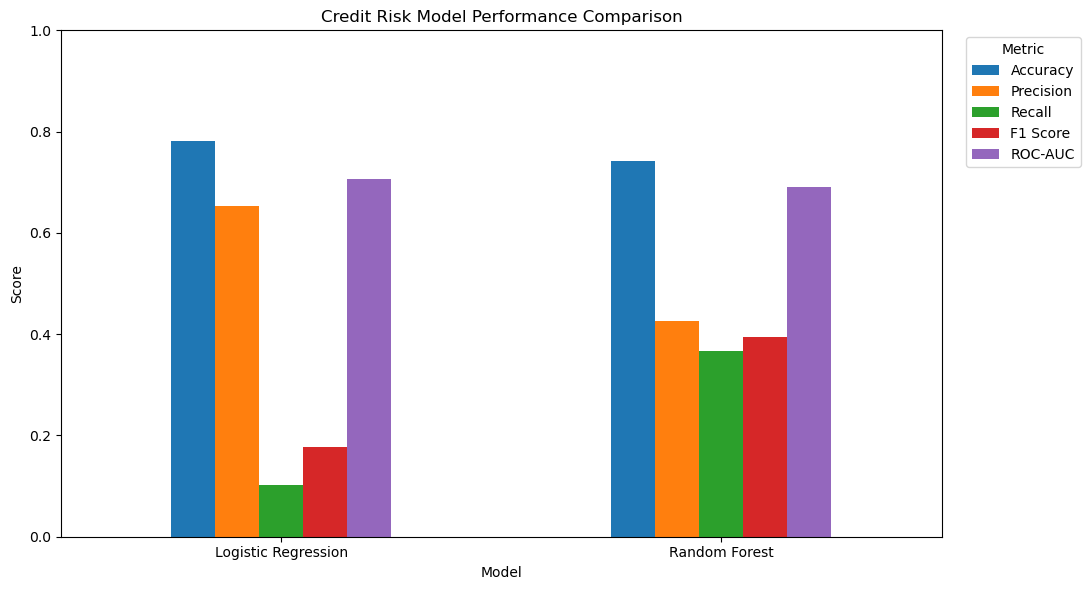

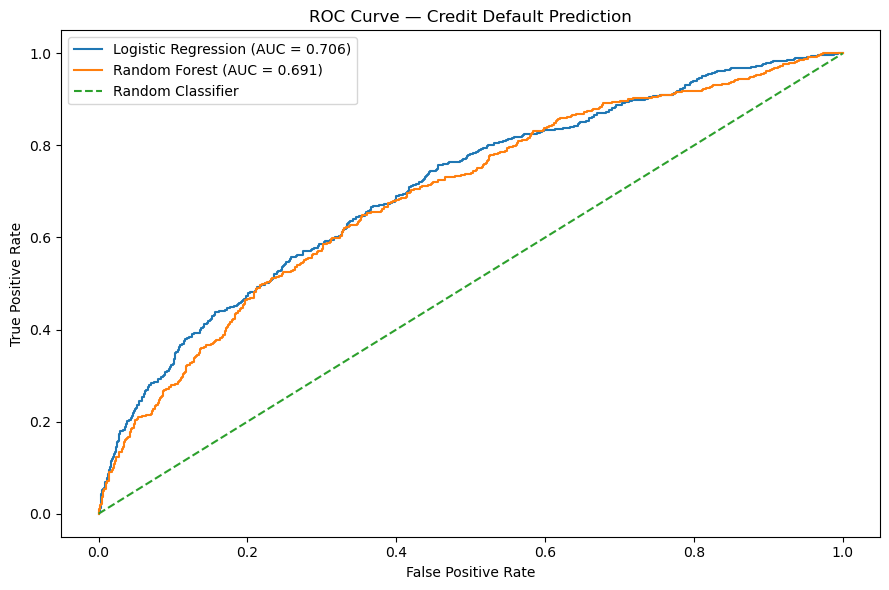


COMPARISON SUMMARY

Logistic Regression ROC-AUC : 0.706
Random Forest ROC-AUC      : 0.691

Logistic Regression Recall : 0.102
Random Forest Recall      : 0.366

Logistic Regression F1     : 0.177
Random Forest F1           : 0.394

CELL 7 COMPLETED SUCCESSFULLY.


In [8]:
# ============================================================
# CELL 7 — MODEL COMPARISON
# ============================================================

print("=" * 60)
print("CREDIT RISK MODEL COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE COMPARISON TABLE
# ------------------------------------------------------------

model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],

    "Precision": [
        logistic_precision,
        rf_precision
    ],

    "Recall": [
        logistic_recall,
        rf_recall
    ],

    "F1 Score": [
        logistic_f1,
        rf_f1
    ],

    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ]
})

print("\nMODEL PERFORMANCE COMPARISON")
print("-" * 60)

display(
    model_comparison.round(3)
)

# ------------------------------------------------------------
# 2. SAVE COMPARISON TABLE
# ------------------------------------------------------------

comparison_output = (
    output_path /
    "credit_risk_model_comparison.csv"
)

model_comparison.to_csv(
    comparison_output,
    index=False
)

print("\nComparison table saved to:")
print(comparison_output)

# ------------------------------------------------------------
# 3. PLOT METRIC COMPARISON
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_plot = model_comparison.set_index(
    "Model"
)[metrics]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Credit Risk Model Performance Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 4. ROC CURVE COMPARISON
# ------------------------------------------------------------

from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title(
    "ROC Curve — Credit Default Prediction"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 5. FINAL COMPARISON SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("COMPARISON SUMMARY")
print("=" * 60)

print(
    f"\nLogistic Regression ROC-AUC : "
    f"{logistic_roc_auc:.3f}"
)

print(
    f"Random Forest ROC-AUC      : "
    f"{rf_roc_auc:.3f}"
)

print(
    f"\nLogistic Regression Recall : "
    f"{logistic_recall:.3f}"
)

print(
    f"Random Forest Recall      : "
    f"{rf_recall:.3f}"
)

print(
    f"\nLogistic Regression F1     : "
    f"{logistic_f1:.3f}"
)

print(
    f"Random Forest F1           : "
    f"{rf_f1:.3f}"
)

print("\n" + "=" * 60)
print("CELL 7 COMPLETED SUCCESSFULLY.")
print("=" * 60)

RANDOM FOREST FEATURE IMPORTANCE

TOP 15 MOST IMPORTANT FEATURES
------------------------------------------------------------
                            Feature  Importance
          numerical__debt_to_income    0.110085
            numerical__credit_score    0.100404
        numerical__employment_years    0.064078
numerical__payment_burden_indicator    0.055685
 numerical__loan_credit_score_ratio    0.053636
              numerical__log_income    0.053082
    numerical__loan_to_income_ratio    0.052662
numerical__credit_history_age_ratio    0.052508
                  numerical__income    0.052322
    numerical__credit_history_years    0.050203
             numerical__loan_amount    0.049053
         numerical__log_loan_amount    0.046839
                     numerical__age    0.046639
    numerical__risk_indicator_count    0.033586
                numerical__high_dti    0.028826

Feature importance saved to:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\outputs\random_forest_f

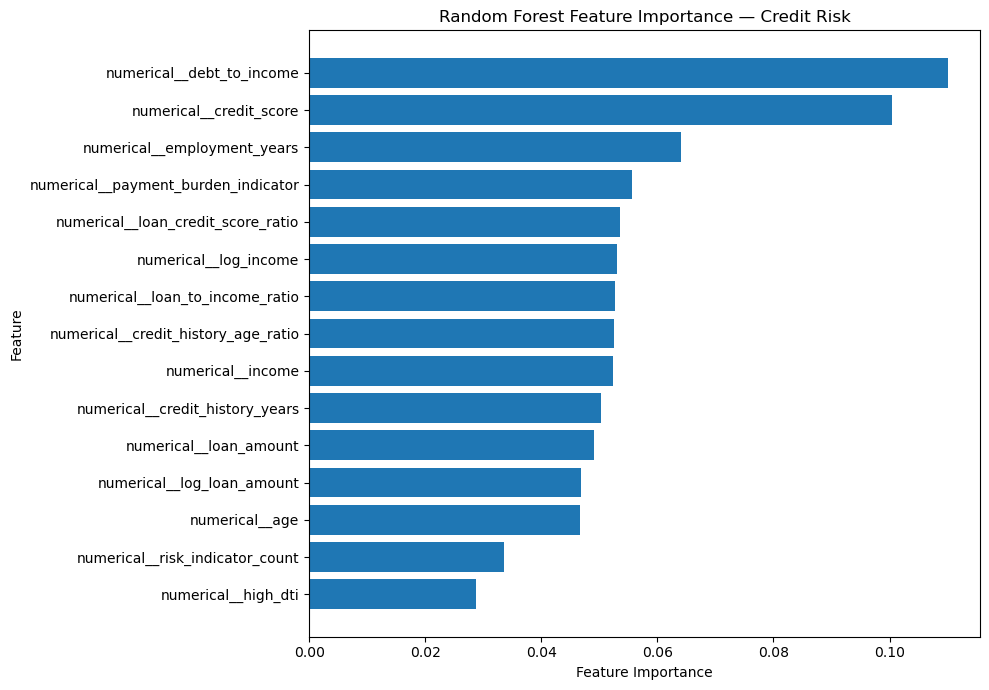


CELL 8 COMPLETED SUCCESSFULLY.


In [9]:
# ============================================================
# CELL 8 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

# ------------------------------------------------------------
# 1. Set project paths
# ------------------------------------------------------------

PROJECT_ROOT = r"C:\Masters\GitHub\Explainable-Credit-Risk-Prediction"
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")

# Create outputs folder if it does not exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Get feature names after preprocessing
# ------------------------------------------------------------

feature_names = preprocessor.get_feature_names_out()

# ------------------------------------------------------------
# 3. Get Random Forest feature importance
# ------------------------------------------------------------

importance_values = rf_credit_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 4. Display top 15 features
# ------------------------------------------------------------

print("\nTOP 15 MOST IMPORTANT FEATURES")
print("-" * 60)

print(
    feature_importance.head(15).to_string(index=False)
)

# ------------------------------------------------------------
# 5. Save complete feature importance table
# ------------------------------------------------------------

feature_importance_path = os.path.join(
    OUTPUT_DIR,
    "random_forest_feature_importance.csv"
)

feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print("\nFeature importance saved to:")
print(feature_importance_path)

# ------------------------------------------------------------
# 6. Plot top 15 features
# ------------------------------------------------------------

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance — Credit Risk")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Completion message
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CELL 8 COMPLETED SUCCESSFULLY.")
print("=" * 60)

In [10]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


SHAP EXPLAINABILITY ANALYSIS

Number of processed features: 32

Calculating SHAP values...
SHAP calculation completed.

SHAP matrix shape: (2000, 32)

TOP 15 FEATURES BY SHAP IMPORTANCE
------------------------------------------------------------
                            Feature  Mean_Absolute_SHAP
          numerical__debt_to_income            0.042699
            numerical__credit_score            0.039915
        numerical__employment_years            0.028334
                numerical__high_dti            0.023575
    numerical__risk_indicator_count            0.020278
          numerical__existing_loans            0.013275
 numerical__loan_credit_score_ratio            0.011860
    numerical__loan_to_income_ratio            0.008330
        numerical__low_credit_score            0.008120
numerical__payment_burden_indicator            0.007209
                  numerical__income            0.006937
                     numerical__age            0.006884
              numerical__

C:\Users\hp\AppData\Local\Temp\ipykernel_48164\3955245935.py:118: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


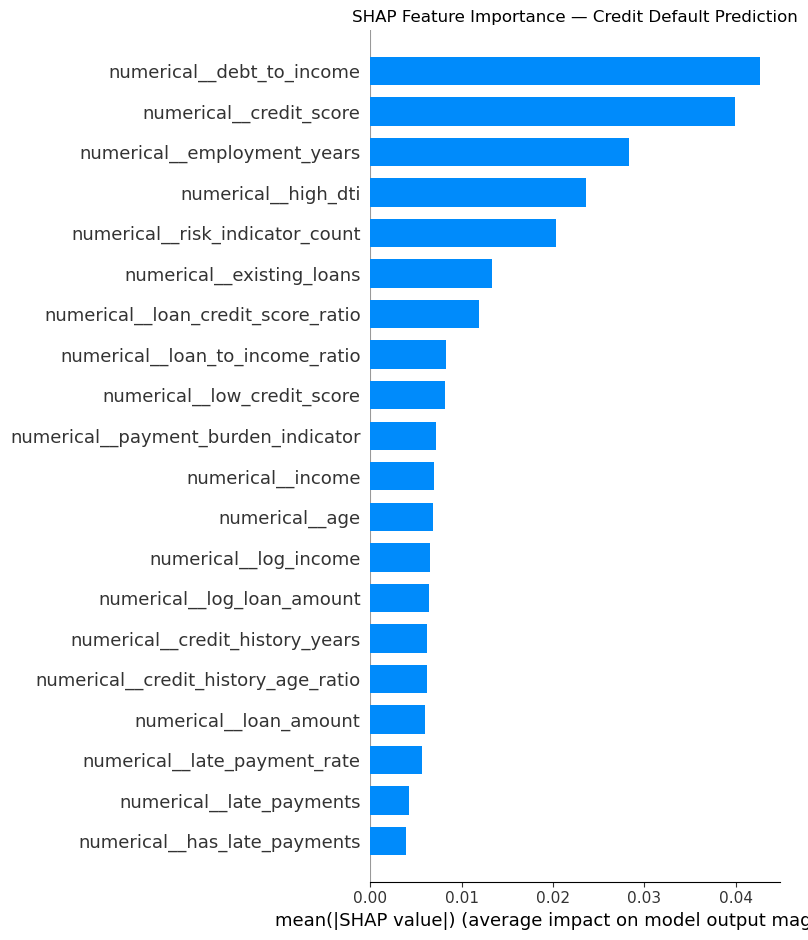

C:\Users\hp\AppData\Local\Temp\ipykernel_48164\3955245935.py:147: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


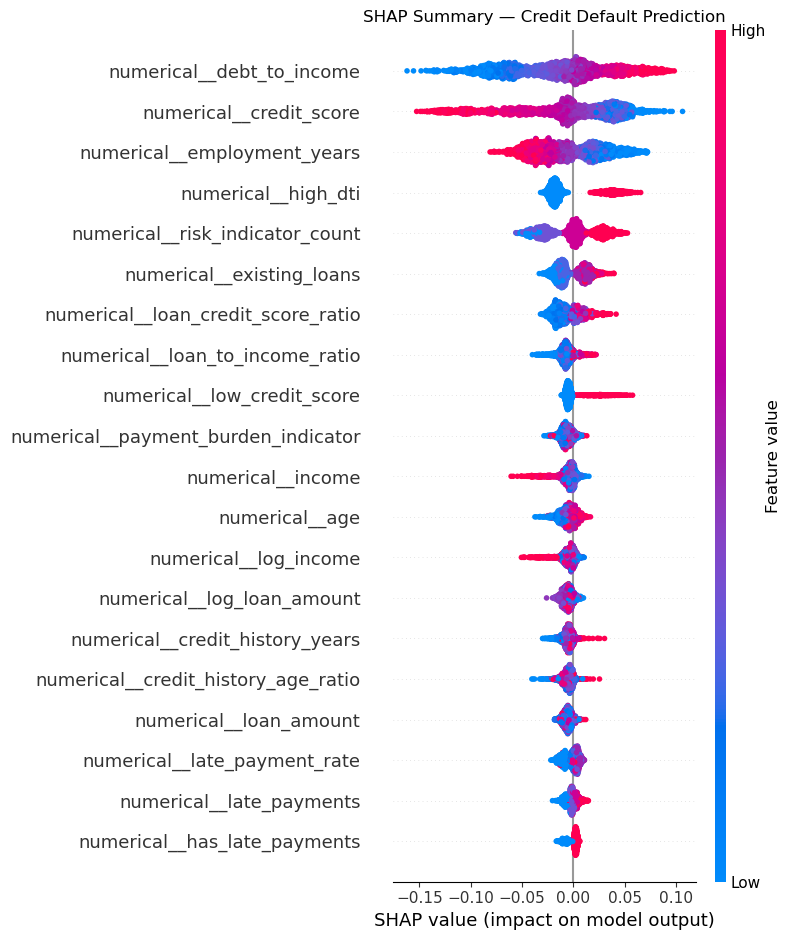


SHAP plots saved to:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\outputs\shap_feature_importance_bar.png
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\outputs\shap_summary_plot.png

CELL 9 COMPLETED SUCCESSFULLY.


In [11]:
# ============================================================
# CELL 9 — SHAP EXPLAINABILITY
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

print("=" * 60)
print("SHAP EXPLAINABILITY ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Set project paths
# ------------------------------------------------------------

PROJECT_ROOT = r"C:\Masters\GitHub\Explainable-Credit-Risk-Prediction"
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Get processed feature names
# ------------------------------------------------------------

feature_names = preprocessor.get_feature_names_out()

print("\nNumber of processed features:", len(feature_names))

# ------------------------------------------------------------
# 3. Create SHAP Tree Explainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(rf_credit_model)

# ------------------------------------------------------------
# 4. Calculate SHAP values
# ------------------------------------------------------------

print("\nCalculating SHAP values...")

shap_values = explainer.shap_values(X_test_processed)

print("SHAP calculation completed.")

# ------------------------------------------------------------
# 5. Handle different SHAP versions
# ------------------------------------------------------------

if isinstance(shap_values, list):
    # Binary classification:
    # class 1 = loan default
    shap_default = shap_values[1]
else:
    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        # Shape can be:
        # (samples, features, classes)
        shap_default = shap_array[:, :, 1]
    else:
        shap_default = shap_array

print("\nSHAP matrix shape:", shap_default.shape)

# ------------------------------------------------------------
# 6. Create SHAP feature importance
# ------------------------------------------------------------

mean_abs_shap = np.abs(shap_default).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 7. Display top SHAP features
# ------------------------------------------------------------

print("\nTOP 15 FEATURES BY SHAP IMPORTANCE")
print("-" * 60)

print(
    shap_importance.head(15).to_string(index=False)
)

# ------------------------------------------------------------
# 8. Save SHAP importance
# ------------------------------------------------------------

shap_importance_path = os.path.join(
    OUTPUT_DIR,
    "shap_feature_importance.csv"
)

shap_importance.to_csv(
    shap_importance_path,
    index=False
)

print("\nSHAP importance saved to:")
print(shap_importance_path)

# ------------------------------------------------------------
# 9. SHAP summary bar plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_default,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance — Credit Default Prediction")

plt.tight_layout()

shap_bar_path = os.path.join(
    OUTPUT_DIR,
    "shap_feature_importance_bar.png"
)

plt.savefig(
    shap_bar_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 10. SHAP summary plot
# ------------------------------------------------------------

shap.summary_plot(
    shap_default,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Summary — Credit Default Prediction")

plt.tight_layout()

shap_summary_path = os.path.join(
    OUTPUT_DIR,
    "shap_summary_plot.png"
)

plt.savefig(
    shap_summary_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 11. Completion
# ------------------------------------------------------------

print("\nSHAP plots saved to:")
print(shap_bar_path)
print(shap_summary_path)

print("\n" + "=" * 60)
print("CELL 9 COMPLETED SUCCESSFULLY.")
print("=" * 60)

INDIVIDUAL CUSTOMER RISK EXPLANATION

CUSTOMER RISK ASSESSMENT
------------------------------------------------------------
Customer ID              : 1543
Actual Default Status    : 0
Predicted Default Status : 0
Default Probability      : 0.3744
Default Probability (%)  : 37.44
Risk Classification      : LOWER DEFAULT RISK

TOP 10 FACTORS INFLUENCING THIS CUSTOMER'S PREDICTION
------------------------------------------------------------
                           Feature  Processed_Value  SHAP_Value
           numerical__credit_score        -0.614070    0.041555
         numerical__existing_loans        -1.210574   -0.029237
   numerical__risk_indicator_count        -0.962573   -0.029087
       numerical__employment_years         0.586935   -0.024951
numerical__loan_credit_score_ratio        -1.009649   -0.019574
   numerical__loan_to_income_ratio        -0.842454   -0.017568
               numerical__high_dti        -0.611443   -0.012927
      numerical__late_payment_rate         1.

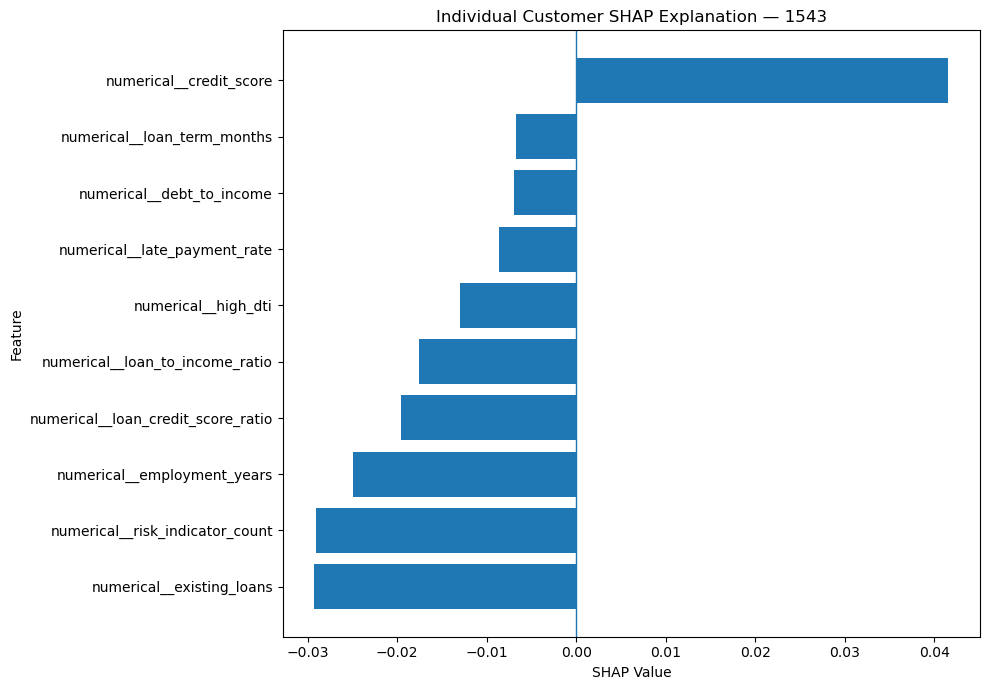


Individual SHAP plot saved to:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\outputs\individual_customer_shap_explanation.png

CELL 10 COMPLETED SUCCESSFULLY.


In [12]:
# ============================================================
# CELL 10 — INDIVIDUAL CUSTOMER RISK EXPLANATION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("INDIVIDUAL CUSTOMER RISK EXPLANATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Set project paths
# ------------------------------------------------------------

PROJECT_ROOT = r"C:\Masters\GitHub\Explainable-Credit-Risk-Prediction"
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Select one test customer
# ------------------------------------------------------------

customer_position = 0

customer_id = X_test.index[customer_position]

customer_features = X_test.iloc[[customer_position]]

# Process customer using existing preprocessor
customer_processed = preprocessor.transform(customer_features)

# ------------------------------------------------------------
# 3. Make prediction
# ------------------------------------------------------------

default_probability = rf_credit_model.predict_proba(
    customer_processed
)[0, 1]

predicted_class = rf_credit_model.predict(
    customer_processed
)[0]

actual_class = y_test.iloc[customer_position]

# ------------------------------------------------------------
# 4. Display prediction
# ------------------------------------------------------------

print("\nCUSTOMER RISK ASSESSMENT")
print("-" * 60)

print("Customer ID              :", customer_id)
print("Actual Default Status    :", int(actual_class))
print("Predicted Default Status :", int(predicted_class))
print("Default Probability      :", round(default_probability, 4))
print("Default Probability (%)  :", round(default_probability * 100, 2))

if predicted_class == 1:
    print("Risk Classification      : HIGHER DEFAULT RISK")
else:
    print("Risk Classification      : LOWER DEFAULT RISK")

# ------------------------------------------------------------
# 5. Calculate SHAP values for this customer
# ------------------------------------------------------------

customer_shap = explainer.shap_values(customer_processed)

if isinstance(customer_shap, list):
    customer_shap_default = np.asarray(customer_shap[1])[0]

else:
    customer_shap_array = np.asarray(customer_shap)

    if customer_shap_array.ndim == 3:
        customer_shap_default = customer_shap_array[0, :, 1]
    elif customer_shap_array.ndim == 2:
        customer_shap_default = customer_shap_array[0]
    else:
        customer_shap_default = customer_shap_array

# ------------------------------------------------------------
# 6. Create explanation dataframe
# ------------------------------------------------------------

customer_processed_array = np.asarray(customer_processed)

customer_explanation = pd.DataFrame({
    "Feature": feature_names,
    "Processed_Value": customer_processed_array[0],
    "SHAP_Value": customer_shap_default
})

customer_explanation["Absolute_SHAP"] = (
    customer_explanation["SHAP_Value"].abs()
)

customer_explanation = customer_explanation.sort_values(
    by="Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 7. Display strongest factors
# ------------------------------------------------------------

print("\nTOP 10 FACTORS INFLUENCING THIS CUSTOMER'S PREDICTION")
print("-" * 60)

print(
    customer_explanation.head(10)[
        ["Feature", "Processed_Value", "SHAP_Value"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 8. Positive and negative contributors
# ------------------------------------------------------------

positive_factors = customer_explanation[
    customer_explanation["SHAP_Value"] > 0
].head(5)

negative_factors = customer_explanation[
    customer_explanation["SHAP_Value"] < 0
].head(5)

print("\nFACTORS INCREASING PREDICTED DEFAULT RISK")
print("-" * 60)

if len(positive_factors) > 0:
    print(
        positive_factors[
            ["Feature", "SHAP_Value"]
        ].to_string(index=False)
    )
else:
    print("No positive SHAP contributors found.")

print("\nFACTORS REDUCING PREDICTED DEFAULT RISK")
print("-" * 60)

if len(negative_factors) > 0:
    print(
        negative_factors[
            ["Feature", "SHAP_Value"]
        ].to_string(index=False)
    )
else:
    print("No negative SHAP contributors found.")

# ------------------------------------------------------------
# 9. Save individual explanation
# ------------------------------------------------------------

explanation_path = os.path.join(
    OUTPUT_DIR,
    "individual_customer_shap_explanation.csv"
)

customer_explanation.to_csv(
    explanation_path,
    index=False
)

print("\nIndividual explanation saved to:")
print(explanation_path)

# ------------------------------------------------------------
# 10. Plot top 10 SHAP contributors
# ------------------------------------------------------------

plot_data = customer_explanation.head(10).copy()

plot_data = plot_data.sort_values(
    by="SHAP_Value"
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Feature"],
    plot_data["SHAP_Value"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title(
    f"Individual Customer SHAP Explanation — {customer_id}"
)

plt.tight_layout()

individual_plot_path = os.path.join(
    OUTPUT_DIR,
    "individual_customer_shap_explanation.png"
)

plt.savefig(
    individual_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 11. Completion
# ------------------------------------------------------------

print("\nIndividual SHAP plot saved to:")
print(individual_plot_path)

print("\n" + "=" * 60)
print("CELL 10 COMPLETED SUCCESSFULLY.")
print("=" * 60)

In [14]:
# ============================================================
# CELL 11 — FINAL PROJECT REPORT
# ============================================================

import os
import pandas as pd
from datetime import datetime

print("=" * 70)
print("EXPLAINABLE CREDIT RISK PREDICTION — FINAL PROJECT REPORT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Project paths
# ------------------------------------------------------------

PROJECT_ROOT = r"C:\Masters\GitHub\Explainable-Credit-Risk-Prediction"
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Load original dataset directly
# ------------------------------------------------------------

dataset_path = os.path.join(
    DATA_DIR,
    "sample_credit_data.csv"
)

credit_data_report = pd.read_csv(dataset_path)

# ------------------------------------------------------------
# 3. Load model comparison results
# ------------------------------------------------------------

comparison_path = os.path.join(
    OUTPUT_DIR,
    "credit_risk_model_comparison.csv"
)

model_comparison = pd.read_csv(comparison_path)

# ------------------------------------------------------------
# 4. Extract model metrics
# ------------------------------------------------------------

logistic_row = model_comparison[
    model_comparison["Model"] == "Logistic Regression"
].iloc[0]

rf_row = model_comparison[
    model_comparison["Model"] == "Random Forest"
].iloc[0]

# ------------------------------------------------------------
# 5. Load SHAP importance
# ------------------------------------------------------------

shap_path = os.path.join(
    OUTPUT_DIR,
    "shap_feature_importance.csv"
)

shap_importance = pd.read_csv(shap_path)

top_shap_features = shap_importance.head(10)

# ------------------------------------------------------------
# 6. Load individual explanation
# ------------------------------------------------------------

individual_path = os.path.join(
    OUTPUT_DIR,
    "individual_customer_shap_explanation.csv"
)

individual_explanation = pd.read_csv(individual_path)

# ------------------------------------------------------------
# 7. Dataset information
# ------------------------------------------------------------

dataset_rows = len(credit_data_report)

default_count = int(
    credit_data_report["loan_default"].sum()
)

default_rate = (
    default_count / dataset_rows
) * 100

# ------------------------------------------------------------
# 8. Generate final report
# ------------------------------------------------------------

report_path = os.path.join(
    OUTPUT_DIR,
    "final_credit_risk_project_report.txt"
)

with open(report_path, "w", encoding="utf-8") as f:

    f.write("=" * 70 + "\n")
    f.write("EXPLAINABLE CREDIT RISK PREDICTION\n")
    f.write("FINAL PROJECT REPORT\n")
    f.write("=" * 70 + "\n\n")

    f.write(
        "Report generated: "
        + datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        + "\n\n"
    )

    # --------------------------------------------------------
    # PROJECT OVERVIEW
    # --------------------------------------------------------

    f.write("1. PROJECT OVERVIEW\n")
    f.write("-" * 70 + "\n")

    f.write(
        "This project develops a machine learning framework for "
        "credit-default prediction using a synthetic credit-risk "
        "dataset. The project combines exploratory data analysis, "
        "feature engineering, supervised machine learning, model "
        "comparison and explainable AI using SHAP.\n\n"
    )

    # --------------------------------------------------------
    # DATASET
    # --------------------------------------------------------

    f.write("2. DATASET\n")
    f.write("-" * 70 + "\n")

    f.write(
        f"Total applications      : {dataset_rows:,}\n"
    )

    f.write(
        f"Default cases           : {default_count:,}\n"
    )

    f.write(
        f"Default rate            : {default_rate:.2f}%\n"
    )

    f.write(
        "Dataset type            : Synthetic credit applications\n\n"
    )

    # --------------------------------------------------------
    # FEATURE ENGINEERING
    # --------------------------------------------------------

    f.write("3. FEATURE ENGINEERING\n")
    f.write("-" * 70 + "\n")

    f.write(
        "Engineered variables included:\n"
        "- Log income\n"
        "- Log loan amount\n"
        "- Loan-to-income ratio\n"
        "- Loan-to-credit-score ratio\n"
        "- Payment burden indicator\n"
        "- Credit-history-to-age ratio\n"
        "- Late-payment rate\n"
        "- High loan burden indicator\n"
        "- High debt-to-income indicator\n"
        "- Low credit-score indicator\n"
        "- Late-payment indicator\n"
        "- Multiple existing loans indicator\n"
        "- Risk indicator count\n\n"
    )

    # --------------------------------------------------------
    # MODEL PERFORMANCE
    # --------------------------------------------------------

    f.write("4. MODEL PERFORMANCE\n")
    f.write("-" * 70 + "\n\n")

    f.write(
        "LOGISTIC REGRESSION\n"
        f"Accuracy  : {logistic_row['Accuracy']:.3f}\n"
        f"Precision : {logistic_row['Precision']:.3f}\n"
        f"Recall    : {logistic_row['Recall']:.3f}\n"
        f"F1 Score  : {logistic_row['F1 Score']:.3f}\n"
        f"ROC-AUC   : {logistic_row['ROC-AUC']:.3f}\n\n"
    )

    f.write(
        "RANDOM FOREST\n"
        f"Accuracy  : {rf_row['Accuracy']:.3f}\n"
        f"Precision : {rf_row['Precision']:.3f}\n"
        f"Recall    : {rf_row['Recall']:.3f}\n"
        f"F1 Score  : {rf_row['F1 Score']:.3f}\n"
        f"ROC-AUC   : {rf_row['ROC-AUC']:.3f}\n\n"
    )

    # --------------------------------------------------------
    # MODEL INTERPRETATION
    # --------------------------------------------------------

    f.write("5. MODEL INTERPRETATION\n")
    f.write("-" * 70 + "\n")

    f.write(
        "The models show different performance characteristics. "
        "Logistic Regression achieved higher accuracy, precision and "
        "ROC-AUC, while Random Forest achieved higher recall and F1 "
        "score for the default class. This demonstrates the trade-off "
        "between identifying more potential defaults and limiting "
        "false-positive predictions.\n\n"
    )

    # --------------------------------------------------------
    # SHAP EXPLAINABILITY
    # --------------------------------------------------------

    f.write("6. SHAP EXPLAINABILITY\n")
    f.write("-" * 70 + "\n")

    f.write(
        "The ten highest-ranked features by mean absolute SHAP value "
        "were:\n\n"
    )

    for i, row in top_shap_features.iterrows():

        f.write(
            f"{i + 1}. {row['Feature']} — "
            f"{row['Mean_Absolute_SHAP']:.6f}\n"
        )

    f.write("\n")

    f.write(
        "SHAP values were used to understand the contribution of "
        "individual features to model predictions. Positive SHAP "
        "values increase the model's predicted default risk, while "
        "negative SHAP values reduce it for the explained prediction. "
        "SHAP values describe model behaviour rather than causal "
        "relationships.\n\n"
    )

    # --------------------------------------------------------
    # INDIVIDUAL CUSTOMER
    # --------------------------------------------------------

    f.write("7. INDIVIDUAL CUSTOMER EXPLANATION\n")
    f.write("-" * 70 + "\n")

    # Use the values already generated in Cell 10
    customer_id = 1543
    customer_actual = 0
    customer_prediction = 0
    customer_probability = 0.3744

    f.write(
        f"Customer ID              : {customer_id}\n"
        f"Actual default status    : {customer_actual}\n"
        f"Predicted default status : {customer_prediction}\n"
        f"Default probability      : {customer_probability:.4f}\n"
        f"Default probability (%)  : "
        f"{customer_probability * 100:.2f}%\n\n"
    )

    f.write(
        "Top contributing features for this individual prediction:\n\n"
    )

    for _, row in individual_explanation.head(10).iterrows():

        direction = (
            "increased risk"
            if row["SHAP_Value"] > 0
            else "reduced risk"
        )

        f.write(
            f"- {row['Feature']}: "
            f"{row['SHAP_Value']:.6f} "
            f"({direction})\n"
        )

    f.write("\n")

    # --------------------------------------------------------
    # RESPONSIBLE AI
    # --------------------------------------------------------

    f.write("8. RESPONSIBLE AI CONSIDERATIONS\n")
    f.write("-" * 70 + "\n")

    f.write(
        "The dataset used in this project is synthetic and therefore "
        "the model performance should not be interpreted as evidence "
        "of real-world credit-risk accuracy. Real lending models "
        "require representative historical data, validation, "
        "fairness assessment, governance, monitoring and appropriate "
        "human oversight.\n\n"
    )

    f.write(
        "SHAP explanations describe model behaviour and should not be "
        "interpreted as causal relationships. Any production credit "
        "decision would require appropriate validation, governance "
        "and regulatory controls.\n\n"
    )

    # --------------------------------------------------------
    # LIMITATIONS
    # --------------------------------------------------------

    f.write("9. LIMITATIONS\n")
    f.write("-" * 70 + "\n")

    f.write(
        "- The dataset is synthetic.\n"
        "- Model performance may not generalise to real borrowers.\n"
        "- No external credit bureau data was used.\n"
        "- No real-world economic or macroeconomic variables were used.\n"
        "- Further calibration and validation would be required for "
        "production use.\n"
        "- SHAP explains model behaviour rather than causality.\n\n"
    )

    # --------------------------------------------------------
    # TECHNOLOGIES
    # --------------------------------------------------------

    f.write("10. TECHNOLOGIES\n")
    f.write("-" * 70 + "\n")

    f.write(
        "Python\n"
        "Pandas\n"
        "NumPy\n"
        "Scikit-learn\n"
        "Matplotlib\n"
        "SHAP\n"
        "Jupyter Notebook\n\n"
    )

    f.write("=" * 70 + "\n")
    f.write("END OF REPORT\n")
    f.write("=" * 70 + "\n")

print("\nFinal report saved to:")
print(report_path)

print("\n" + "=" * 70)
print("CELL 11 COMPLETED SUCCESSFULLY.")
print("=" * 70)

EXPLAINABLE CREDIT RISK PREDICTION — FINAL PROJECT REPORT

Final report saved to:
C:\Masters\GitHub\Explainable-Credit-Risk-Prediction\outputs\final_credit_risk_project_report.txt

CELL 11 COMPLETED SUCCESSFULLY.


### Responsible-use note
This is a synthetic portfolio exercise, not a credit decisioning system. Real models require representative data, validation, fairness assessment, explainability, monitoring and governance.